# Image Classification with CIFAR-10 Dataset and Scikit-Learn

In this notebook, we will explore the basics of image classification using the CIFAR-10 dataset and build a simple image classifier using Scikit-Learn. We will perform the following steps:
1. Load and preprocess the CIFAR-10 dataset.
2. Extract features from the images.
3. Train a machine learning model on the extracted features.
4. Evaluate the model's performance.

## Step 1: Installing and Importing Libraries

### Installing Libraries

Before we start, we need to ensure that we have all the necessary libraries installed. We can use `!pip install` to install any missing libraries directly from the Jupyter Notebook. This command is useful for installing Python packages from the Python Package Index (PyPI).

### Why Install Libraries?

Libraries provide pre-written code that we can use to perform various tasks without having to write everything from scratch. Installing libraries ensures we have access to the necessary functions and tools needed for our project.

Here are the libraries we need for this notebook:
- **numpy:** For numerical operations.
- **matplotlib:** For plotting and visualizing images.
- **tensorflow:** For loading the CIFAR-10 dataset.
- **scikit-learn (sklearn):** For machine learning models and evaluation metrics.

### Installing Libraries Individually vs. All at Once


You can install each library separately by writing a `!pip install` command for each library. This looks like:
```python
!pip install numpy
!pip install matplotlib
!pip install tensorflow
!pip install scikit-learn


Alternatively, you can install all the libraries together in a single !pip install command by separating the library names with a space

!pip install numpy matplotlib tensorflow scikit-learn

## Differences and Considerations
- **Convenience**: Installing all libraries at once is more convenient and requires fewer lines of code. It can save time when writing and running the notebook.
- **Execution Time**: Running a single !pip install command can be faster than running multiple commands, as it reduces the overhead of initiating separate installation processes for each library.
- **Dependency Management**: Installing libraries together can help Pip resolve dependencies more efficiently, potentially avoiding conflicts that might arise when installing libraries separately.
- **Debugging**: Installing libraries individually can make it easier to identify which specific library caused an issue if an installation error occurs. However, this is generally only a concern if you encounter frequent installation problems.

For this notebook, we will install all necessary libraries together for convenience.

In [37]:
# EXTRA CODE BLOCK #1 — CIFAR‑10 Dataset Loading

from tensorflow.keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()


In [38]:
!pip install numpy matplotlib tensorflow scikit-learn


### Importing Libraries

After installing the libraries, we need to import them into our notebook. Importing libraries allows us to use their functionalities in our code. Each library is imported using an alias (short name) to make the code cleaner and more readable.

Let's import the required libraries:


In [39]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score


## Step 2: Loading and Preprocessing the CIFAR-10 Dataset

The CIFAR-10 dataset is readily available in the `keras` library. We will load the dataset and preprocess it by converting the images to grayscale and flattening them.


In [40]:
# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# To minimize computational demands lets work with three classes of your choice

# CIFAR-10 classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


# Choose a subset of classes
chosen_classes = ['cat', 'dog', 'horse']
class_indices = [class_names.index(cls) for cls in chosen_classes]

In [41]:
# Filter data for the chosen classes
mask_train = np.isin(y_train, class_indices)
mask_test = np.isin(y_test, class_indices)
X_train_subset = X_train[mask_train.flatten()]
y_train_subset = y_train[mask_train]
X_test_subset = X_test[mask_test.flatten()]
y_test_subset = y_test[mask_test]


In [42]:
# Convert images to grayscale
X_train_gray = np.dot(X_train_subset[...,:3], [0.2989, 0.5870, 0.1140])
X_test_gray = np.dot(X_test_subset[...,:3], [0.2989, 0.5870, 0.1140])

# Normalize the images
X_train_normalized = X_train_gray / 255.0
X_test_normalized = X_test_gray / 255.0

# Flatten the images
X_train_flat = X_train_normalized.reshape(X_train_normalized.shape[0], -1)
X_test_flat = X_test_normalized.reshape(X_test_normalized.shape[0], -1)




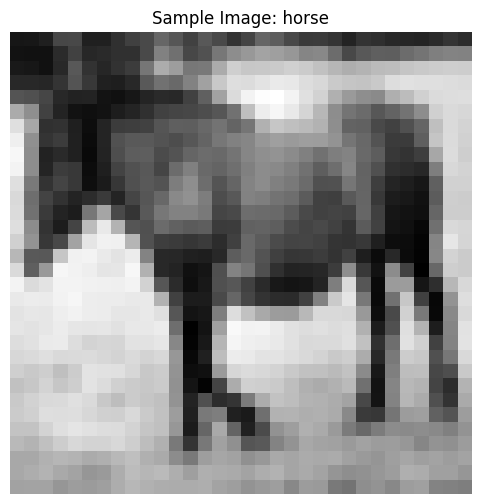

Training set size: (15000, 1024)
Testing set size: (3000, 1024)


In [43]:
# Display a sample image
plt.figure(figsize=(6, 6))
plt.imshow(X_train_gray[0], cmap='gray')
plt.title(f'Sample Image: {chosen_classes[np.where(class_indices == y_train_subset[0])[0][0]]}')
plt.axis('off')
plt.show()

print("Training set size:", X_train_flat.shape)
print("Testing set size:", X_test_flat.shape)

## Step 3: Training a Machine Learning Model

### What is SVM (Support Vector Machine)?

Support Vector Machine (SVM) is a supervised machine learning algorithm that can be used for both classification and regression tasks. However, it is mostly used for classification problems. The objective of the SVM algorithm is to find a hyperplane in an N-dimensional space (N is the number of features) that distinctly classifies the data points.

### Key Concepts:

- **Hyperplane:** A decision boundary that separates different classes in the feature space. In 2D, it's a line; in 3D, it's a plane.
- **Support Vectors:** Data points that are closest to the hyperplane and influence its position and orientation. These points help in maximizing the margin of the classifier.
- **Margin:** The distance between the hyperplane and the closest data points from either class. SVM aims to maximize this margin.

### Why Use SVM?

- **Effective in high-dimensional spaces:** SVM is very effective when the number of features is large.
- **Memory efficient:** It uses a subset of training points (support vectors) in the decision function, making it memory efficient.
- **Versatile:** Different kernel functions can be specified for the decision function. Common kernels include linear, polynomial, and radial basis function (RBF).

### What does `SVC(kernel='linear')` mean?

`SVC` stands for Support Vector Classification, which is a class in the Scikit-Learn library used to implement the SVM algorithm for classification tasks. The `kernel` parameter in the `SVC` class specifies the type of hyperplane used to separate the data.

#### Kernel Types:

- **Linear Kernel:** The data is linearly separable (i.e., a straight line or hyperplane can separate the data). This is the simplest kernel.
  - When we use `SVC(kernel='linear')`, it means we are using a linear kernel for our SVM. This kernel is appropriate when the data can be separated by a straight line (or hyperplane in higher dimensions).
- **Polynomial Kernel:** The data is not linearly separable, but a polynomial function of the input features can separate the data.
- **Radial Basis Function (RBF) Kernel:** The data is not linearly separable, but mapping the data into a higher-dimensional space using a Gaussian (RBF) function can separate the data.

### Training the SVM Model

We will use a Support Vector Machine (SVM) classifier from Scikit-Learn to train our model on the extracted features.


In [44]:
# Train an SVM classifier
model = SVC(kernel='linear')
model.fit(X_train_flat, y_train_subset.ravel())

# Predict on the test set
y_pred = model.predict(X_test_flat)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test_subset, y_pred))
print("Classification Report:\n", classification_report(y_test_subset, y_pred, target_names=chosen_classes))




Accuracy: 0.45866666666666667
Classification Report:
               precision    recall  f1-score   support

         cat       0.42      0.40      0.41      1000
         dog       0.46      0.47      0.46      1000
       horse       0.49      0.51      0.50      1000

    accuracy                           0.46      3000
   macro avg       0.46      0.46      0.46      3000
weighted avg       0.46      0.46      0.46      3000



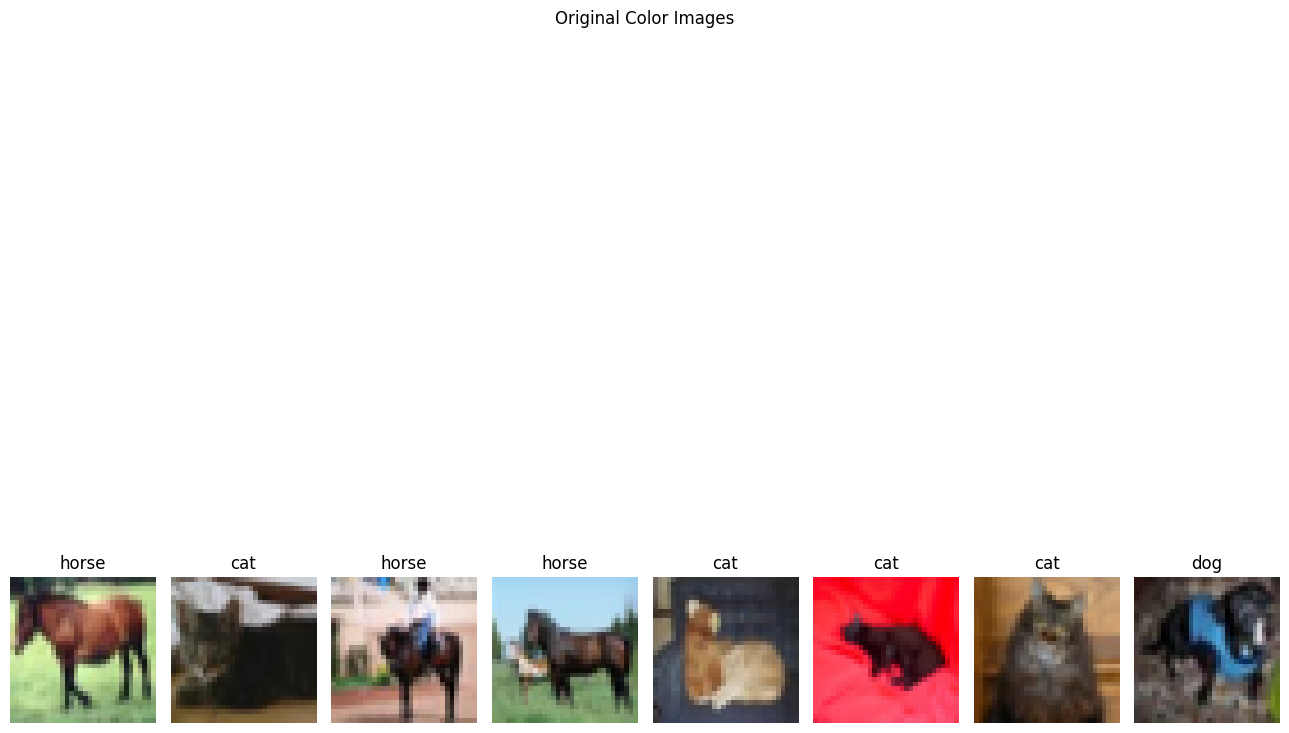

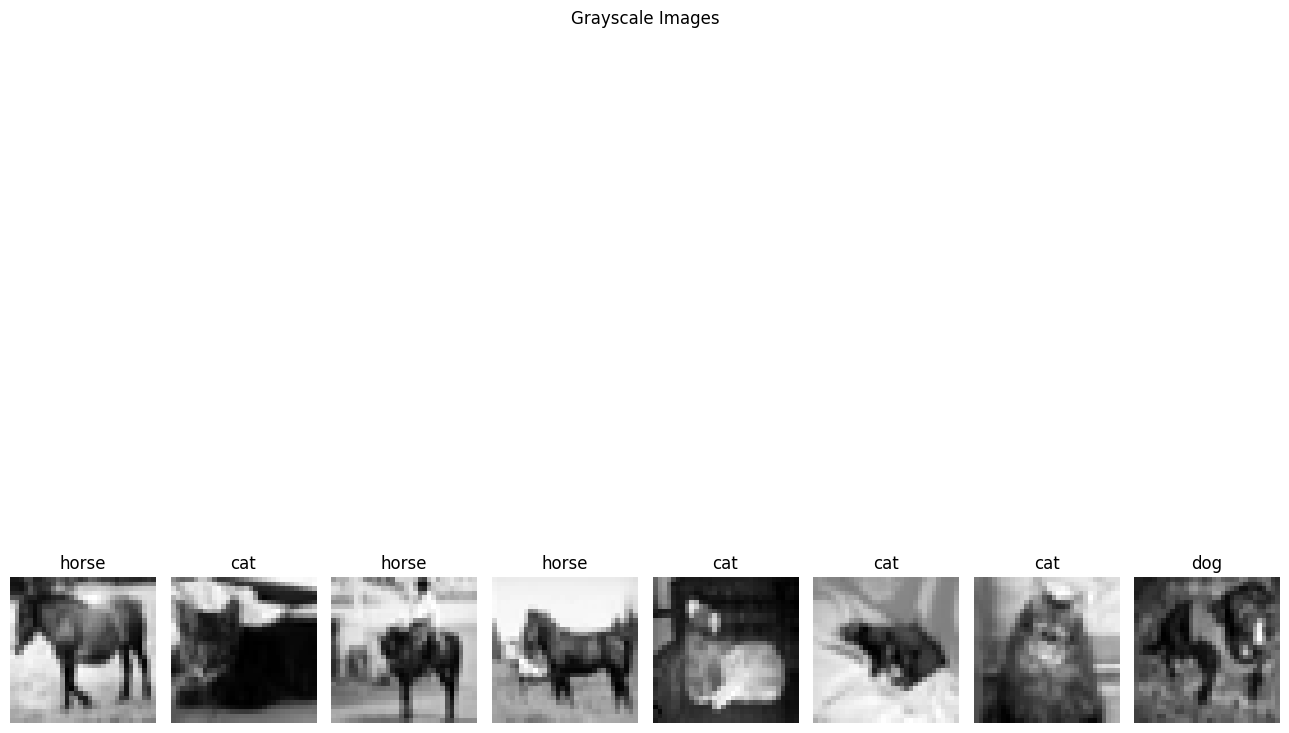

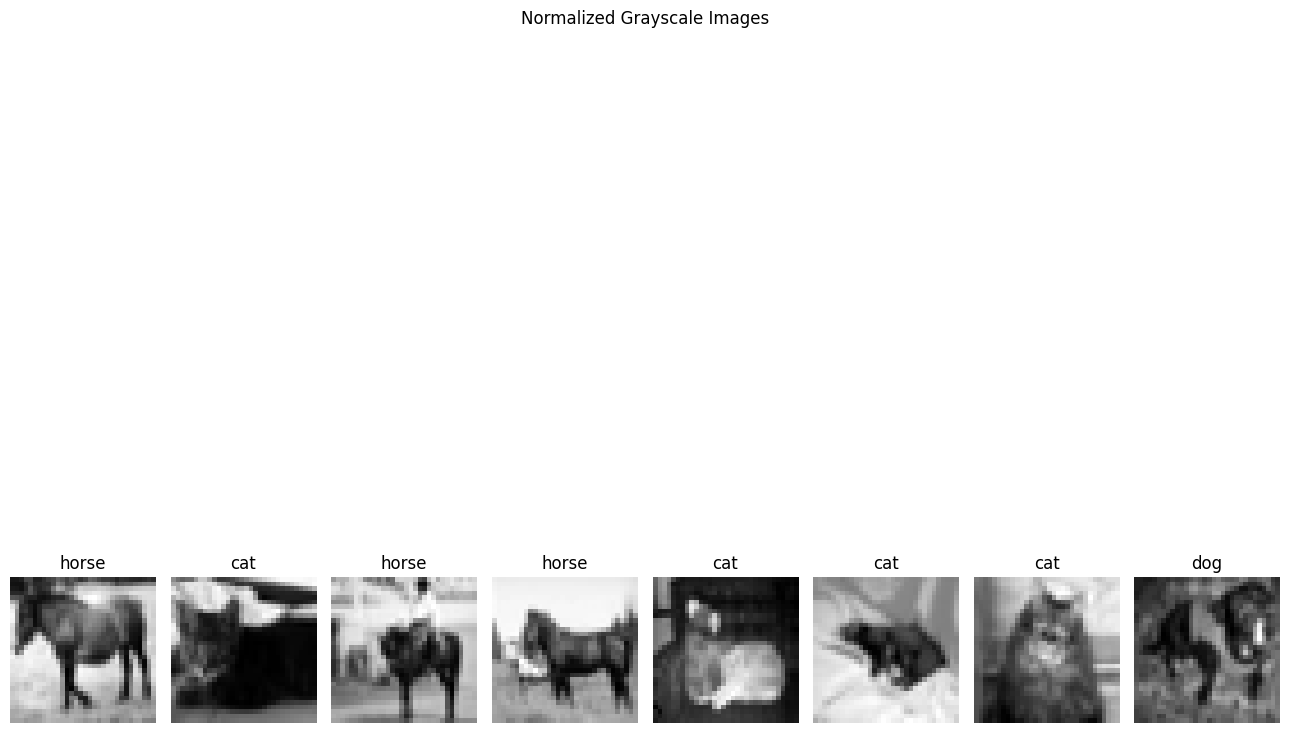

In [45]:
# Lets see some images of the  datasset in the different stages
# Function to display images
def display_images(images, titles, main_title, cmap=None):
    fig, axes = plt.subplots(1, 8, figsize=(13, 13))
    fig.suptitle(main_title)
    for i, ax in enumerate(axes):
        if cmap:
            ax.imshow(images[i], cmap=cmap)
        else:
            ax.imshow(images[i])
        ax.set_title(titles[i])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Display original color images
display_images(X_train_subset[:8],
               [chosen_classes[np.where(class_indices == y)[0][0]] for y in y_train_subset[:8]],
               'Original Color Images')

# Display grayscale images
display_images(X_train_gray[:8],
               [chosen_classes[np.where(class_indices == y)[0][0]] for y in y_train_subset[:8]],
               'Grayscale Images', cmap='gray')

# Display normalized images
display_images(X_train_normalized[:8],
               [chosen_classes[np.where(class_indices == y)[0][0]] for y in y_train_subset[:8]],
               'Normalized Grayscale Images', cmap='gray')

## Step 4: Conclusion

In this notebook, we:
1. Loaded and preprocessed the CIFAR-10 dataset.
2. Converted the images to grayscale and flattened them to use as features.
3. Trained an SVM classifier on the extracted features.
4. Evaluated the model's performance.

### Summary of SVM

Support Vector Machines (SVM) are a powerful tool for classification tasks. They work by finding the optimal hyperplane that maximizes the margin between different classes. The key points include:
- **Hyperplane:** The decision boundary.
- **Support Vectors:** Critical data points that define the hyperplane.
- **Margin:** The gap between the hyperplane and the nearest data points from any class.

SVMs are effective in high-dimensional spaces and are versatile due to the use of different kernel functions. However, they can be computationally intensive for large datasets and less effective for overlapping classes.

This exercise provided a basic introduction to image classification using classical machine learning techniques. Next  few modules will explore advanced applications, using deep learning models like Convolutional Neural Networks (CNNs) using libraries such as TensorFlow or PyTorch.


Reflection on Learning:

• Describe your understanding of the SVM algorithm and its application in image
classification.


It is a supervised ML algorithm that can be used for classification or regression tasks.
It is capable of handling a large number of features but is also memory efficient and it has a wide variety of flavors, so to speak, depending on what type of filter or kernel is needed: linear, polynomial and radial basis function.

There are 3 key concepts:

Hyperplane – a decision boundary separating classes which is  a line in 2d and a plane in 3d.

Support vectors – most influential data points that define the hyperplane.
Margin – the distance between the hyperplane and the nearest support vectors – SVM wants to maximizes the distance to improve generalization.

In this lab, I used SVC(kernel=’linear’), which applies a linear decision boundary.  This kernel is computationally efficient and appropriate for introductory image classification tasks.


• Reflect on the data preparation steps, model training, and evaluation process.

•	Working with CIFAR-10 required several processing steps:

•	Load the CIFAR-10 dataset using TensorFlow’s built-in CIFAR-10 loader.

•	I selected three classes (cat, dog, horse) to reduce the computational load.

•	Next, filtering the data for the chosen classes to only include cat, dog, horse.

•	Selecting the RGB channels of each image and applying the luminance formula that converts RGB to grayscale using human-perception weighting. SVM doesn’t need color and this reduces the complexity.

•	Grayscale is computed as: Gray=0.2989R+0.5870G+0.1140B

•	The images pixels were then normalized to the range of 0 to 255 and dividing by 255.0 scales all the values to the range of 0 to 1. It improves model stability and accuracy.

•	Finally, the images were flattened.  Each grayscale image is 32 x 32 pixels. Flattening turns each image into a 1D vector of length 1024.  32 x 32 = 1024 features. Each image would be a row, and each column would be one pixel value. SVMs don’t understand images, they understand feature vectors.  Stacking all the vectors creates a 2D matrix which SVM uses to train.

•	After preprocessing, I trained an SVM classifier:
model = SVC(kernel='linear')
model.fit(X_train_flat, y_train_subset.ravel())
The model learned to classify grayscale images based on pixel intensity patterns. The linear kernel provided a clear baseline for understand how SVMs separate classes in high-dimensional feature space.

•	Finally, I evaluated the model using:
Accuracy score
Classification report
Looking at the predictions plotted to help me understand misclassifications and model behavior.

• Discuss challenges faced, how you addressed them, and insights from the model's
performance.

High dimensionality – Flattening images produced 1024 features and restricted the dataset to three classes – dog, cat, horse – to reduce the training time.
Understanding grayscale – The weighted RGB formula was new. I researched how luminance is computed using perceptual weighting.
Maintaining label consistency – Filtering classes required careful mapping.  I used np.where and class index mapping to ensure accuracy. I also increased the number of mapped images just to see if dog would show up in the first 25 images in the dataset.

I also wanted to see why the dogs never showed up in the original code and just how many images were needed to see the dogs. I modified the code to have more images and reduced them in size so they could be seen. I started with 25 images and found that the dog showed up at image 8 so just adjusted the figsize to 13x13 and plotting the first 8 images.  I also had to reduce the pdf scale so that it would correctly print the displayed images.

### Additional Learning
I have also decided to try some additional learning.  The following extra code blocks are the product of lots of trial and error.

Code block 1

I added this at the top because it initializes the full CIFAR-10 dataset which I learned the hard way that I needed.  It let me experiment with additional preprocessing steps beyond the require lab.  By loading the complete dataset I was able to explore class filtering, visualization and SVM training on a subset of classes to better understand how image classification pipelines are constructed.

Code block 2

Imported StandardScaler, a tool that standardizes features by removing the mean and scaling to unit variance. I added this to understand how preprocessing affects SVM.  I wanted to see how scaling influences model accuracy and stability.

Code block 3

I learned the hard way that I needed to reduce the dataset since it kept crashing Colab. I was able to continue experimenting with different kernels and hyperparameters without runtime failures. So, I learned once again about computational trade-offs in machine learning and why SVMs are rarely used with large image datasets. SVMs scale quadratically with the number of samples and overloaded the computational capability.

Code block 4

This code block really challenged me. It crashed so many times because it was even more demanding computationally than the linear kernel.  The dataset was once again reduced.

Code block 5

Once again, I had to reduce the dataset because polynomial SVMs are even more demanding than the RBF model!  Several Colab crashes and my attempt to use a GPU to fool it made me change it to X_train_small and X_test_small.

Code block 6

More crashing with my initial attempts. I was pretty frustrated. More dataset size reduction. At this point I just realized that I had to go smaller. Hyperparameter tuning has high computational requirements and Colab was overworked.  

Code block 7

I needed to sum up everything and look at it for the best SVM model. And this code block didn't work on my first attempt either. Of course it was too big! But it was because I had a mismatch in the number of samples. My test size did not match the number of predictions.   

The Confusion matrix tells me the model was best at recognizing horses. It had the most confidence and accuracy because horse bodies and faces are more distinct from cats and dogs which more closely resemble each other in comparison to horses. The model struggled with cats the most because dogs and cats are pretty similar in shapes, how they stand, and in their fur/texture. Dogs did a little better than cats but the model still struggles confusing dogs with cats.

Code block 8

More Colab crashing. More reducing dataset size and re-running.

Code block 9

Had to rerun the model on a reduced subset. So now I had all three kernels able to run on the same size dataset.

Code block 10

After training the polynomial SVM and the best model selected by GridSearchCV,  I had to calculate their accuracies using the same reduced set. I used these accuracy values for the comparison table.

Code block 11

This comparison table reflects the calculated accuracy values of the models under identical conditions. It is based on all the models evaluated using the same dataset size. The RBF SVM model performed best, the Linear SVM model performed worst.  GridSearchCV did not perform better than RBF SVM and did not show any major improvements from tuning.

In [46]:
# EXTRA CODE BLOCK #2 — Feature Scaling with StandardScaler

from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)


In [47]:
# EXTRA CODE BLOCK #3 — Dataset Reduction (Revised With Real‑World Setbacks)

# Reduce dataset size for SVM to avoid Colab crashes
X_train_small = X_train_scaled[:2000]
y_train_small = y_train_subset[:2000]

X_test_small = X_test_scaled[:500]
y_test_small = y_test_subset[:500]


In [48]:
# EXTRA CODE BLOCK #4 — Training an SVM with the RBF Kernel

model_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
model_rbf.fit(X_train_scaled, y_train_subset.ravel())

# Predict
y_pred_rbf = model_rbf.predict(X_test_scaled)

# Evaluate
print("RBF Kernel Accuracy:", accuracy_score(y_test_subset, y_pred_rbf))
print("\nClassification Report (RBF Kernel):\n")
print(classification_report(y_test_subset, y_pred_rbf, target_names=chosen_classes))


RBF Kernel Accuracy: 0.623

Classification Report (RBF Kernel):

              precision    recall  f1-score   support

         cat       0.57      0.59      0.58      1000
         dog       0.59      0.54      0.57      1000
       horse       0.70      0.74      0.72      1000

    accuracy                           0.62      3000
   macro avg       0.62      0.62      0.62      3000
weighted avg       0.62      0.62      0.62      3000



In [49]:
# EXTRA CODE BLOCK #5 — Polynomial Kernel SVM (Safe Version)
model_poly = SVC(kernel='poly', degree=3, C=1.0, gamma='scale')
model_poly.fit(X_train_small, y_train_small.ravel())

# Predict
y_pred_poly = model_poly.predict(X_test_small)

# Evaluate
print("Polynomial Kernel Accuracy:", accuracy_score(y_test_small, y_pred_poly))
print("\nClassification Report (Polynomial Kernel):\n")
print(classification_report(y_test_small, y_pred_poly, target_names=chosen_classes))



Polynomial Kernel Accuracy: 0.472

Classification Report (Polynomial Kernel):

              precision    recall  f1-score   support

         cat       0.44      0.53      0.48       173
         dog       0.44      0.32      0.37       158
       horse       0.54      0.56      0.55       169

    accuracy                           0.47       500
   macro avg       0.47      0.47      0.47       500
weighted avg       0.47      0.47      0.47       500



In [50]:
# EXTRA CODE BLOCK #6 — Hyperparameter Tuning with GridSearchCV

from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1],
    'gamma': ['scale', 0.01],
    'kernel': ['rbf', 'poly'],
    'degree': [2, 3]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_small, y_train_small.ravel())

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Score:", grid.best_score_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_small)

print("\nTest Accuracy (Best Model):", accuracy_score(y_test_small, y_pred_best))
print("\nClassification Report (Best Model):\n")
print(classification_report(y_test_small, y_pred_best, target_names=chosen_classes))


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation Score: 0.547513030271651

Test Accuracy (Best Model): 0.518

Classification Report (Best Model):

              precision    recall  f1-score   support

         cat       0.47      0.46      0.47       173
         dog       0.48      0.39      0.43       158
       horse       0.58      0.70      0.64       169

    accuracy                           0.52       500
   macro avg       0.51      0.52      0.51       500
weighted avg       0.51      0.52      0.51       500



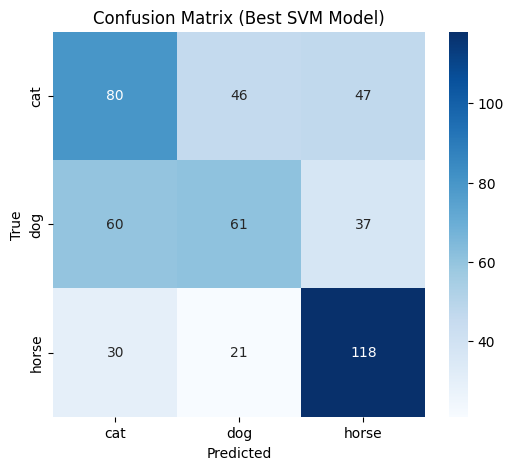

In [51]:
# EXTRA CODE BLOCK #7 — Confusion Matrix for the Best SVM Model

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_small, y_pred_best)


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=chosen_classes,
            yticklabels=chosen_classes)
plt.title("Confusion Matrix (Best SVM Model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [52]:
# EXTRA CODE BLOCK #8 — Linear SVM on the Reduced Dataset

# Re-run Linear SVM on the SMALL dataset
model_linear = SVC(kernel='linear')
model_linear.fit(X_train_small, y_train_small.ravel())

# Predictions
y_pred_linear = model_linear.predict(X_test_small)

# Accuracy
linear_accuracy = accuracy_score(y_test_small, y_pred_linear)
linear_accuracy



0.344

In [53]:
# EXTRA CODE BLOCK #9 — RBF SVM on the Reduced Dataset

# Re-run RBF SVM on the SMALL dataset
model_rbf = SVC(kernel='rbf', C=1, gamma='scale')
model_rbf.fit(X_train_small, y_train_small.ravel())

# Predictions
y_pred_rbf = model_rbf.predict(X_test_small)

# Accuracy
rbf_accuracy = accuracy_score(y_test_small, y_pred_rbf)
rbf_accuracy



0.518

In [54]:
# EXTRA CODE BLOCK #10 — Computing Accuracy for Polynomial and Best Models

poly_accuracy = accuracy_score(y_test_small, y_pred_poly)
best_accuracy = accuracy_score(y_test_small, y_pred_best)


In [55]:
# EXTRA CODE BLOCK #11 — Building a Model Comparison Table

import pandas as pd

results = {
    'Model': ['Linear SVM', 'RBF SVM', 'Polynomial SVM', 'Best GridSearch Model'],
    'Accuracy': [
        linear_accuracy,        # replace with your variable
        rbf_accuracy,           # replace with your variable
        poly_accuracy,          # replace with your variable
        accuracy_score(y_test_small, y_pred_best)
    ]
}

df_results = pd.DataFrame(results)
df_results


,Model,Accuracy
0,Linear SVM,0.344
1,RBF SVM,0.518
2,Polynomial SVM,0.472
3,Best GridSearch Model,0.518
